# 01 — Data Processing & Feature Engineering

This notebook turns the raw M5 Forecasting data into a clean, model-ready daily demand dataset.

The goal is to create **one row per item–store–day** with:

- product and store information
- calendar and event information
- SNAP and selling price information
- historical demand features such as lags and rolling averages

The resulting dataset is saved as a Parquet file for use by the modeling notebooks.


## Project decisions

A few choices in this notebook are deliberate:

- **Use the full historical sales period**, rather than keeping only the most recent year. The data contains 1,941 recorded sales days, and the long history captures both recurring seasonality and the clear growth in demand over time.
- **Keep the raw target as daily unit sales.** The forecasting problem is: given an item and store on a particular day, predict how many units will be sold.
- **Build lag and rolling features using only earlier sales.** Every rolling feature uses `shift(1)` first so the current day's sales never leak into its own predictors.
- **Retain missing-price information explicitly.** Every row with a missing selling price has zero recorded sales, so the missingness itself is informative. We therefore keep a `price_missing` flag and fill the numerical price field with 0 only as a placeholder.
- **Do not create the train/validation/test split here.** The split is handled in `02_model_training.ipynb` so preprocessing stays independent of model selection.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 1. Load the raw datasets

The M5 data is split across three files:

- `calendar.csv` — dates, weekdays, events and SNAP indicators
- `sales_train_evaluation.csv` — item/store sales history
- `sell_prices.csv` — weekly selling prices by item and store

The relative paths below keep the notebook portable inside the project repository instead of tying it to one computer's absolute file path.


In [ ]:
from pathlib import Path

DATA_DIR = Path("../data/raw/m5-forecasting-accuracy")

calendar_path = DATA_DIR / "calendar.csv"
sales_path = DATA_DIR / "sales_train_evaluation.csv"
prices_path = DATA_DIR / "sell_prices.csv"

for path in [calendar_path, sales_path, prices_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing dataset: {path}")

calendar = pd.read_csv(calendar_path)
sales = pd.read_csv(sales_path)
sell_prices = pd.read_csv(prices_path)


## 2. Initial dataset overview

The raw files have very different shapes because the sales table is stored in **wide format**: each day is a separate column (`d_1`, `d_2`, ...).

That wide layout is convenient for the original competition format, but it is not convenient for machine learning. We will convert it to a long, one-row-per-item-store-day format later.


In [ ]:
print("Calendar shape:", calendar.shape)
print("Sales shape:", sales.shape)
print("Sell prices shape:", sell_prices.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1947)
Sell prices shape: (6841121, 4)


### Inspect the raw schemas

For the sales table, the important identifier columns are `item_id`, `dept_id`, `cat_id`, `store_id`, and `state_id`. The remaining `d_*` columns contain the daily target values.


In [ ]:
print("CALENDAR")
display(calendar.head())

print("\nSALES — identifiers + first 5 sales days")
display(
    sales[
        ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"] + sales.columns[:5].tolist()
    ].head()
)

print("\nSELL PRICES")
display(sell_prices.head())


In [ ]:
print("CALENDAR INFO")
calendar.info()

print("\nSALES INFO")
sales.info()

print("\nSELL PRICES INFO")
sell_prices.info()

CALENDAR INFO
<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB

SALES INFO
<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 454.7 MB

SELL PRICES INFO
<cla

In [ ]:
print("Missing values in Calendar:")
display(calendar.isnull().sum().sort_values(ascending=False))

print("\nMissing values in Sales:")
display(sales.isnull().sum().sort_values(ascending=False).head(20))

print("\nMissing values in Sell Prices:")
display(sell_prices.isnull().sum())

Missing values in Calendar:


event_name_2    1964
event_type_2    1964
event_name_1    1807
event_type_1    1807
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64


Missing values in Sales:


id        0
d_1273    0
d_1301    0
d_1300    0
d_1299    0
d_1298    0
d_1297    0
d_1296    0
d_1295    0
d_1294    0
d_1293    0
d_1292    0
d_1291    0
d_1290    0
d_1289    0
d_1288    0
d_1287    0
d_1286    0
d_1285    0
d_1284    0
dtype: int64


Missing values in Sell Prices:


store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [ ]:
print("Calendar duplicates:", calendar.duplicated().sum())
print("Sales duplicates:", sales.duplicated().sum())
print("Sell prices duplicates:", sell_prices.duplicated().sum())

Calendar duplicates: 0
Sales duplicates: 0
Sell prices duplicates: 0


### Data quality check

The raw tables contain no duplicate rows. Missing event fields in the calendar are expected because most dates have no event; these are handled later by creating consolidated event features.


## 3. Exploratory analysis

Before transforming the data, we use a few targeted summaries to understand the demand structure.

The most important questions are:

1. How sparse is demand?
2. Do stores and categories behave differently?
3. Is there weekly, monthly or yearly seasonality?
4. Do events appear to affect demand?
5. How does price behave?
6. How strongly does recent demand relate to future demand?

These findings guide the feature engineering choices later in the notebook.


In [ ]:
# Selecting only the daily sales columns
sales_cols = [col for col in sales.columns if col.startswith("d_")]

# Total units sold
total_sales = sales[sales_cols].sum().sum()

# Average daily sales across all item-store combinations
average_daily_sales = sales[sales_cols].mean().mean()

# Number of zero-sales observations
zero_sales = (sales[sales_cols] == 0).sum().sum()

# Total observations
total_observations = sales[sales_cols].size

# Percentage of zero-sales observations
zero_percentage = (zero_sales / total_observations) * 100

print("Total units sold:", total_sales)
print("Average daily sales per item-store:", average_daily_sales)
print("Zero-sales observations:", zero_sales)
print("Percentage of zero-sales observations:", zero_percentage)

Total units sold: 66927173
Average daily sales per item-store: 1.1308878055473464
Zero-sales observations: 40241819
Percentage of zero-sales observations: 67.99776584040612


### Store-level demand

A raw sales total is not enough to judge store performance by itself. In this dataset, every store contains the same number of item-store series, so differences in total units sold are not simply caused by one store carrying more products.

This makes store-level sales a useful signal of genuine demand differences across locations.


In [ ]:
store_sales = (
    sales.groupby("store_id")[sales_cols]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

display(store_sales)

store_id
CA_3    11363540
CA_1     7832248
TX_2     7329642
WI_2     6697988
WI_3     6542557
TX_3     6205940
CA_2     5818395
TX_1     5692823
WI_1     5261506
CA_4     4182534
dtype: int64

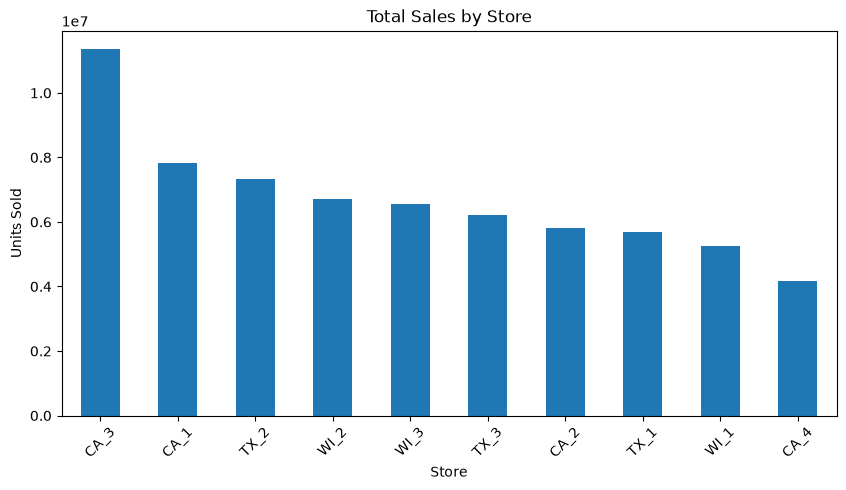

In [ ]:
import matplotlib.pyplot as plt

store_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

### Category-level demand

The three broad categories have very different sales volumes. This motivates keeping both `cat_id` and the more granular `dept_id` as model features.


In [ ]:
category_sales = (
    sales.groupby("cat_id")[sales_cols]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

display(category_sales)

cat_id
FOODS        45922427
HOUSEHOLD    14764090
HOBBIES       6240656
dtype: int64

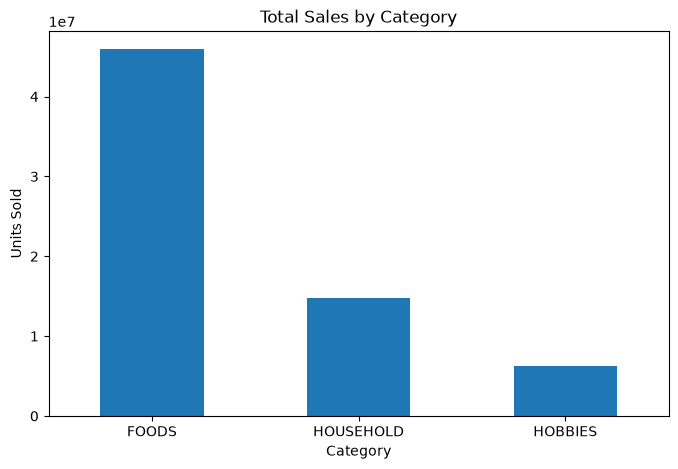

In [ ]:
category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.show()

### Demand over time

Aggregating sales across every item-store combination reveals both short-term fluctuations and a clear long-term upward trend.

This is one reason we decided to retain the **full historical period** rather than restricting the model to just one year.


In [ ]:
daily_sales = sales[sales_cols].sum()

display(daily_sales.head())

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

In [ ]:
dates = calendar[calendar["d"].isin(sales_cols)]["date"]

dates = pd.to_datetime(dates)

daily_sales.index = dates.values

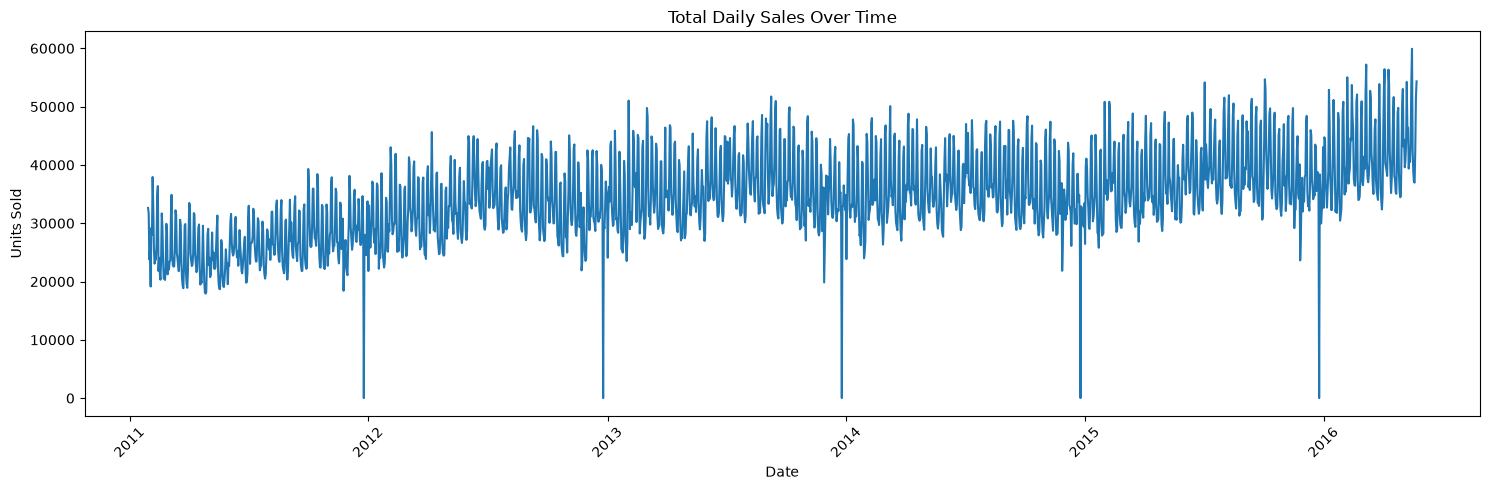

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(daily_sales)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Weekly seasonality

Demand varies much more strongly by weekday than it does across months. Weekend demand is notably higher, so `wday` is an important model feature.


In [ ]:
# Create a dataframe containing daily total sales and the corresponding date
daily_analysis = pd.DataFrame({
    "date": dates.values,
    "sales": daily_sales.values
})

# Extract weekday
daily_analysis["weekday"] = daily_analysis["date"].dt.day_name()

# Average sales for each day of the week
weekday_sales = (
    daily_analysis
    .groupby("weekday")["sales"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

display(weekday_sales)

weekday
Monday       32994.931408
Tuesday      30500.483755
Wednesday    30130.418773
Thursday     30321.039711
Friday       34357.472924
Saturday     41706.269784
Sunday       41304.050360
Name: sales, dtype: float64

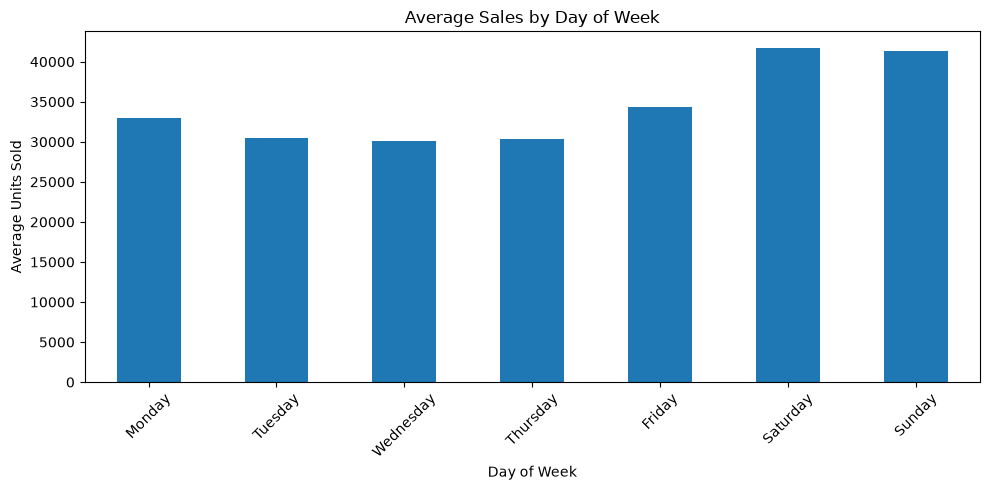

In [ ]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Monthly seasonality

Monthly effects are present but relatively modest compared with the weekday pattern. We retain `month` as a potentially useful secondary calendar feature rather than relying on it alone.


In [ ]:
monthly_sales = (
    daily_analysis
    .assign(month=daily_analysis["date"].dt.month)
    .groupby("month")["sales"]
    .mean()
)

display(monthly_sales)

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34432.183333
5     34085.192090
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: sales, dtype: float64

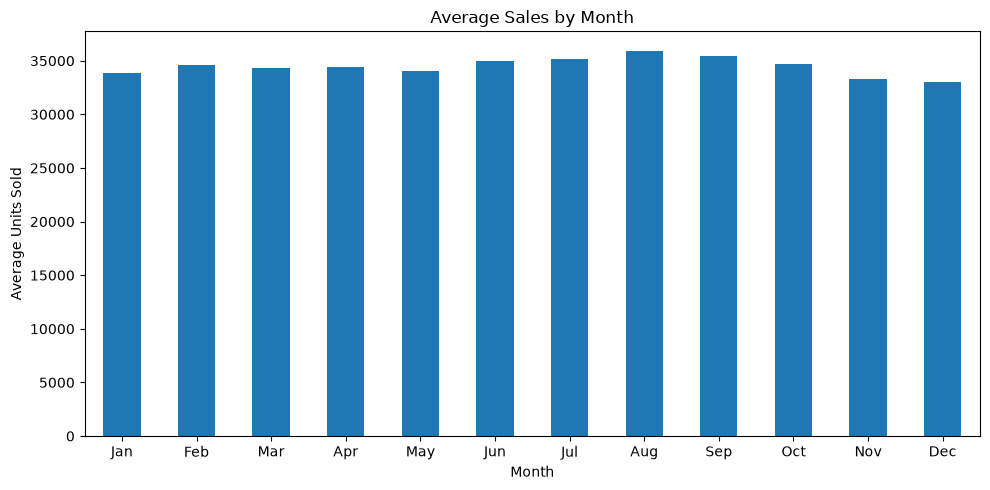

In [ ]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Long-term trend

Average daily sales rise substantially across the observed years. The model therefore needs access to year information in addition to short-term lag features.


In [ ]:
yearly_sales = (
    daily_analysis
    .assign(year=daily_analysis["date"].dt.year)
    .groupby("year")["sales"]
    .mean()
)

display(yearly_sales)

year
2011    26280.667656
2012    32955.838798
2013    35988.364384
2014    35862.400000
2015    37810.441096
2016    41835.041958
Name: sales, dtype: float64

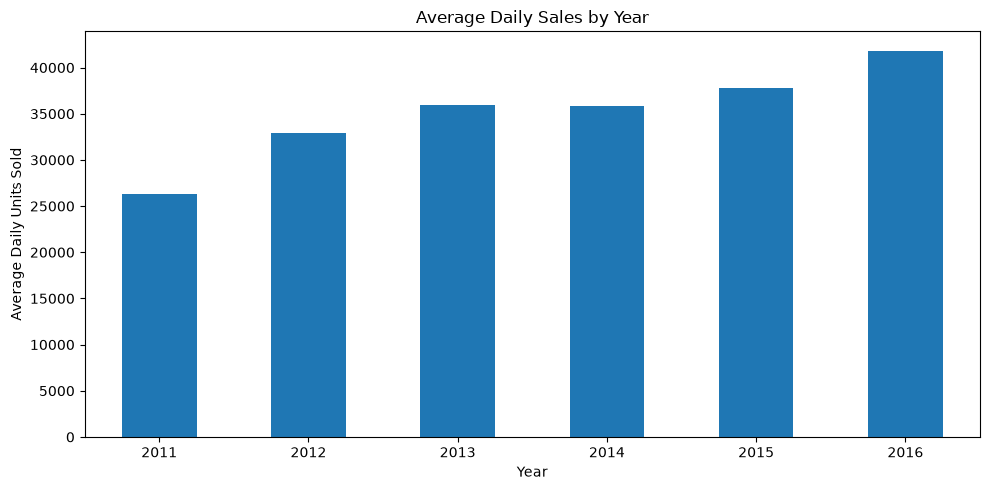

In [ ]:
plt.figure(figsize=(10, 5))

yearly_sales.plot(kind="bar")

plt.title("Average Daily Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Daily Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Events: a caution about averages

A simple event-day vs non-event-day comparison can be misleading because event days are not evenly distributed across weekdays.

To reduce this confounding effect, we also compare event and normal days **within each weekday**. This is a better way to understand whether events add information beyond the normal weekly pattern.


In [ ]:
# Add event indicator to our daily analysis
event_calendar = calendar[calendar["d"].isin(sales_cols)].copy()

event_calendar["has_event"] = (
    event_calendar["event_name_1"].notna() |
    event_calendar["event_name_2"].notna()
)

event_calendar["date"] = pd.to_datetime(event_calendar["date"])

daily_analysis["has_event"] = event_calendar["has_event"].values

# Compare average sales on event vs non-event days
event_sales = (
    daily_analysis
    .groupby("has_event")["sales"]
    .mean()
)

display(event_sales)

has_event
False    34609.336511
True     33029.911392
Name: sales, dtype: float64

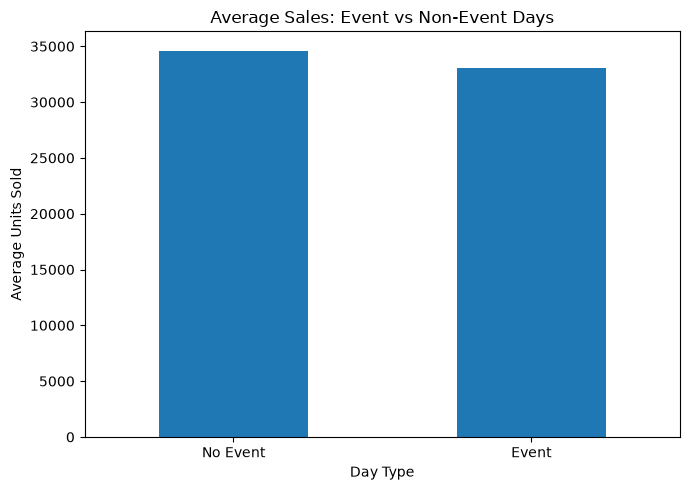

In [ ]:
event_sales.index = ["No Event", "Event"]

event_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Average Sales: Event vs Non-Event Days")
plt.xlabel("Day Type")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
event_counts = (
    calendar["event_name_1"]
    .dropna()
    .value_counts()
)

display(event_counts)

event_name_1
SuperBowl              6
ValentinesDay          6
PresidentsDay          6
LentStart              6
LentWeek2              6
StPatricksDay          6
Purim End              6
Pesach End             6
Mother's day           6
MemorialDay            6
NBAFinalsStart         6
NBAFinalsEnd           6
Ramadan starts         6
OrthodoxEaster         5
Cinco De Mayo          5
IndependenceDay        5
Eid al-Fitr            5
LaborDay               5
ColumbusDay            5
Halloween              5
EidAlAdha              5
VeteransDay            5
Thanksgiving           5
Christmas              5
Chanukah End           5
NewYear                5
OrthodoxChristmas      5
MartinLutherKingDay    5
Easter                 5
Father's day           4
Name: count, dtype: int64

In [ ]:
event_counts_2 = (
    calendar["event_name_2"]
    .dropna()
    .value_counts()
)

display(event_counts_2)

event_name_2
Father's day      2
Easter            1
Cinco De Mayo     1
OrthodoxEaster    1
Name: count, dtype: int64

In [ ]:
# Add weekday to the event calendar
event_analysis = calendar[calendar["d"].isin(sales_cols)].copy()

event_analysis["date"] = pd.to_datetime(event_analysis["date"])

event_analysis["has_event"] = (
    event_analysis["event_name_1"].notna() |
    event_analysis["event_name_2"].notna()
)

# Add the daily sales
event_analysis["sales"] = daily_sales.values

# Compare event vs non-event sales within each weekday
weekday_event_sales = (
    event_analysis
    .groupby(["weekday", "has_event"])["sales"]
    .mean()
    .unstack()
)

display(weekday_event_sales)

has_event,False,True
weekday,,
Friday,34505.509294,29379.750000
Monday,32859.643154,33900.611111
Saturday,41689.674157,42109.090909
Sunday,41831.460251,38071.974359
Thursday,30467.252000,28967.222222
Tuesday,30645.455939,28135.625000
Wednesday,30324.812500,27760.666667


In [ ]:
weekday_event_sales.columns = ["Normal Day", "Event Day"]

display(weekday_event_sales)

,Normal Day,Event Day
weekday,,
Friday,34505.509294,29379.750000
Monday,32859.643154,33900.611111
Saturday,41689.674157,42109.090909
Sunday,41831.460251,38071.974359
Thursday,30467.252000,28967.222222
Tuesday,30645.455939,28135.625000
Wednesday,30324.812500,27760.666667


### Price behavior

Prices are heavily concentrated at lower values and are right-skewed. Most item-store combinations have relatively few unique prices, but some products change price repeatedly.

That makes `sell_price` a useful feature while also motivating a missing-price indicator rather than assuming every missing value represents an actual price of zero.


In [ ]:
sell_prices["sell_price"].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

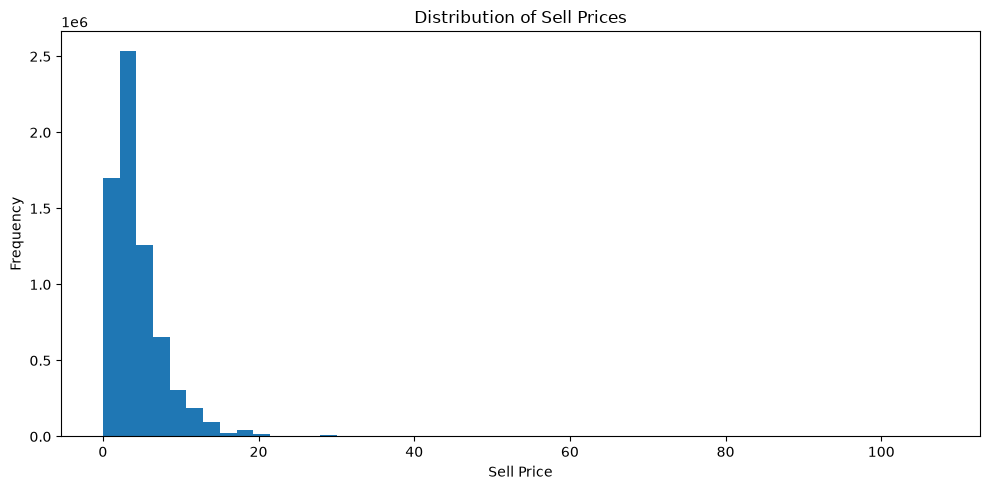

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(sell_prices["sell_price"], bins=50)

plt.title("Distribution of Sell Prices")
plt.xlabel("Sell Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
print("Unique prices:", sell_prices["sell_price"].nunique())

Unique prices: 1048


In [ ]:
price_changes = (
    sell_prices
    .sort_values(["store_id", "item_id", "wm_yr_wk"])
    .groupby(["store_id", "item_id"])["sell_price"]
    .nunique()
)

print("Average number of unique prices per item-store:",
      price_changes.mean())

print("Items with only one price:",
      (price_changes == 1).sum())

print("Items with more than one price:",
      (price_changes > 1).sum())

print("Maximum number of unique prices for one item-store:",
      price_changes.max())

Average number of unique prices per item-store: 2.7693670055755986
Items with only one price: 8247
Items with more than one price: 22243
Maximum number of unique prices for one item-store: 21


In [ ]:
example_prices = (
    sell_prices[
        (sell_prices["store_id"] == "CA_1") &
        (sell_prices["item_id"] == "FOODS_3_090")
    ]
    .sort_values("wm_yr_wk")
)

display(example_prices.head(20))

,store_id,item_id,wm_yr_wk,sell_price
530695,CA_1,FOODS_3_090,11101,1.25
530696,CA_1,FOODS_3_090,11102,1.25
530697,CA_1,FOODS_3_090,11103,1.25
530698,CA_1,FOODS_3_090,11104,1.25
530699,CA_1,FOODS_3_090,11105,1.25
530700,CA_1,FOODS_3_090,11106,1.25
530701,CA_1,FOODS_3_090,11107,1.25
530702,CA_1,FOODS_3_090,11108,1.25
530703,CA_1,FOODS_3_090,11109,1.25
530704,CA_1,FOODS_3_090,11110,1.25


In [ ]:
example_prices = example_prices.copy()

example_prices["price_changed"] = (
    example_prices["sell_price"].diff().fillna(0) != 0
)

display(
    example_prices[example_prices["price_changed"]]
)

,store_id,item_id,wm_yr_wk,sell_price,price_changed
530728,CA_1,FOODS_3_090,11134,1.28,True
530750,CA_1,FOODS_3_090,11204,1.44,True
530755,CA_1,FOODS_3_090,11209,1.48,True
530768,CA_1,FOODS_3_090,11222,1.28,True
530783,CA_1,FOODS_3_090,11237,1.38,True
530785,CA_1,FOODS_3_090,11239,1.25,True
530799,CA_1,FOODS_3_090,11301,1.38,True
530828,CA_1,FOODS_3_090,11330,1.00,True
530835,CA_1,FOODS_3_090,11337,1.38,True
530843,CA_1,FOODS_3_090,11345,1.00,True


In [ ]:
print("Minimum price:",
      example_prices["sell_price"].min())

print("Maximum price:",
      example_prices["sell_price"].max())

print("Number of unique prices:",
      example_prices["sell_price"].nunique())

Minimum price: 1.0
Maximum price: 1.6
Number of unique prices: 8


### Temporal dependence

For one example item-store series, sales are positively correlated with recent history:

- yesterday's sales are strongly related to today's demand
- the same day last week is also informative
- the relationship weakens as the lag gets longer

These results motivate using several lag features rather than relying on a single previous-day value.


In [ ]:
# Extract one item-store combination
example_sales = sales[
    (sales["item_id"] == "FOODS_3_090") &
    (sales["store_id"] == "CA_1")
].iloc[0][sales_cols]

example_sales = example_sales.astype(float)

# Autocorrelation at different lags
print("Correlation with previous day:",
      example_sales.autocorr(lag=1))

print("Correlation with same day last week:",
      example_sales.autocorr(lag=7))

print("Correlation with 14 days ago:",
      example_sales.autocorr(lag=14))

print("Correlation with 28 days ago:",
      example_sales.autocorr(lag=28))

Correlation with previous day: 0.7287813886195563
Correlation with same day last week: 0.6254821990292624
Correlation with 14 days ago: 0.5205619080324783
Correlation with 28 days ago: 0.42158344709487633


## 4. Reshape sales data to one row per item–store–day

We will use **all 1,941 recorded sales days**.

The raw sales table contains 30,490 item-store series and 1,941 daily sales columns. Converting from wide to long format gives a structure that is much easier to merge with calendar and price information and directly usable for supervised learning.


In [ ]:
# Use the complete historical sales period.
model_sales_cols = sales_cols

print("Number of sales days:", len(model_sales_cols))
print("First sales day:", model_sales_cols[0])
print("Last sales day:", model_sales_cols[-1])


In [ ]:
# Columns that identify each item-store combination
id_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

# Convert daily sales from wide format to long format
sales_long = sales[id_cols + model_sales_cols].melt(
    id_vars=id_cols,
    var_name="d",
    value_name="sales"
)

print("Shape:", sales_long.shape)
display(sales_long.head())

Shape: (59181090, 7)


,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


The resulting long-format table has one row for each observed item-store-day. This is the foundation for all subsequent merges and historical features.


In [ ]:
calendar_features = calendar[
    [
        "d",
        "date",
        "wm_yr_wk",
        "weekday",
        "wday",
        "month",
        "year",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
        "snap_CA",
        "snap_TX",
        "snap_WI"
    ]
].copy()

calendar_features["date"] = pd.to_datetime(
    calendar_features["date"]
)

In [ ]:
sales_long = sales_long.merge(
    calendar_features,
    on="d",
    how="left"
)

print("Shape after calendar merge:", sales_long.shape)
display(sales_long.head())

Shape after calendar merge: (59181090, 20)


,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


## 5. Add a state-specific SNAP feature

The calendar stores SNAP eligibility separately for California, Texas and Wisconsin. Since every sales row already contains `state_id`, these three columns can be collapsed into a single `snap` feature.


In [ ]:
sales_long["snap"] = np.where(
    sales_long["state_id"] == "CA",
    sales_long["snap_CA"],
    np.where(
        sales_long["state_id"] == "TX",
        sales_long["snap_TX"],
        sales_long["snap_WI"]
    )
)

In [ ]:
sales_long.drop(
    columns=["snap_CA", "snap_TX", "snap_WI"],
    inplace=True
)

## 6. Merge selling prices

Selling prices are recorded by `store_id`, `item_id`, and `wm_yr_wk`, so the price table is merged at that same grain.

A missing price after the merge is not automatically treated as a real zero price; we investigate those missing records before deciding how to encode them.


In [ ]:
price_features = sell_prices[
    [
        "store_id",
        "item_id",
        "wm_yr_wk",
        "sell_price"
    ]
]

sales_long = sales_long.merge(
    price_features,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print("Shape after price merge:", sales_long.shape)

Shape after price merge: (59181090, 19)


In [ ]:
print("Final shape:", sales_long.shape)

print("\nMissing values:")
print("Dates:", sales_long["date"].isna().sum())
print("Sales:", sales_long["sales"].isna().sum())
print("Prices:", sales_long["sell_price"].isna().sum())

print("\nDuplicate rows:", sales_long.duplicated().sum())

Final shape: (59181090, 19)

Missing values:
Dates: 0
Sales: 0
Prices: 12299413

Duplicate rows: 0


### Investigating missing prices

This is an important data-quality decision rather than a routine imputation step.

In the full merged dataset, **12,299,413 rows have no recorded selling price**. We check whether these missing-price rows correspond to actual positive demand before deciding how to handle them.


In [ ]:
# How many rows have missing prices?
missing_price = sales_long["sell_price"].isna()

print("Missing price rows:", missing_price.sum())
print("Missing price percentage:",
      missing_price.mean() * 100)

# Are there sales on days where price is missing?
print("\nSales on missing-price rows:")

print("Total sales:",
      sales_long.loc[missing_price, "sales"].sum())

print("Non-zero sales rows:",
      (sales_long.loc[missing_price, "sales"] > 0).sum())

print("Total missing-price rows:",
      missing_price.sum())

Missing price rows: 12299413
Missing price percentage: 20.782673992655422

Sales on missing-price rows:
Total sales: 0
Non-zero sales rows: 0
Total missing-price rows: 12299413


The year distribution shows that missing prices are concentrated in the earlier part of the product histories. We also inspect the prevalence of missing prices across item-store combinations.


In [ ]:
missing_by_year = (
    sales_long.loc[missing_price]
    .groupby("year")
    .size()
)

display(missing_by_year)

year
2011    5167100
2012    3933782
2013    2259520
2014     839570
2015      98928
2016        513
dtype: int64

In [ ]:
missing_price_rate = (
    sales_long
    .groupby(["item_id", "store_id"])["sell_price"]
    .apply(lambda x: x.isna().mean())
)

display(
    missing_price_rate
    .describe()
)

count    30490.000000
mean         0.207827
std          0.245237
min          0.000000
25%          0.000000
50%          0.079341
75%          0.393096
max          0.948480
Name: sell_price, dtype: float64

The decisive check is whether a missing price ever coincides with a positive sales observation. In this dataset, every missing-price row has zero sales.

Therefore, we do **not** try to invent a price. Instead:

1. create `price_missing = 1` for these rows
2. fill `sell_price` with 0 only so the numerical feature contains no missing values

The indicator preserves the information that the zero price is a placeholder rather than a real observed selling price.


In [ ]:
missing_price = sales_long["sell_price"].isna()

print("Missing-price rows:", missing_price.sum())

print("Missing-price rows with ZERO sales:",
      (sales_long.loc[missing_price, "sales"] == 0).sum())

print("Missing-price rows with POSITIVE sales:",
      (sales_long.loc[missing_price, "sales"] > 0).sum())

print(
    "Percentage of missing-price rows with positive sales:",
    (
        (sales_long.loc[missing_price, "sales"] > 0).mean() * 100
    )
)

Missing-price rows: 12299413
Missing-price rows with ZERO sales: 12299413
Missing-price rows with POSITIVE sales: 0
Percentage of missing-price rows with positive sales: 0.0


In [ ]:
# Create an indicator for missing price
sales_long["price_missing"] = sales_long["sell_price"].isna().astype("int8")

# Fill missing prices with 0
sales_long["sell_price"] = sales_long["sell_price"].fillna(0)

# Check
print("Missing sell prices:", sales_long["sell_price"].isna().sum())
print("Price-missing indicator:", sales_long["price_missing"].sum())

Missing sell prices: 0
Price-missing indicator: 12299413


## 7. Create lag features

Lag features let the model use previous demand for the same item-store combination.

For example:

- `lag_1` = sales yesterday
- `lag_2` = sales two days ago
- `lag_3` = sales three days ago
- `lag_7` = sales one week ago
- `lag_14` = sales two weeks ago
- `lag_28` = sales four weeks ago

The short lags capture recent momentum, while the weekly and longer lags capture recurring patterns.


In [ ]:
sales_long.sort_values(
    ["item_id", "store_id", "date"],
    inplace=True
)

sales_long.reset_index(drop=True, inplace=True)

In [ ]:
group = sales_long.groupby(
    ["item_id", "store_id"],
    sort=False
)["sales"]

sales_long["lag_1"] = group.shift(1)
sales_long["lag_2"] = group.shift(2)
sales_long["lag_3"] = group.shift(3)
sales_long["lag_7"] = group.shift(7)
sales_long["lag_14"] = group.shift(14)
sales_long["lag_28"] = group.shift(28)

lag_cols = [
    "lag_1", "lag_2", "lag_3",
    "lag_7", "lag_14", "lag_28"
]

sales_long[lag_cols] = sales_long[lag_cols].astype("float32")


In [ ]:
display(
    sales_long[
        (sales_long["item_id"] == "FOODS_3_090") &
        (sales_long["store_id"] == "CA_1")
    ][
        ["date", "sales", "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28"]
    ].head(35)
)


Notice that the first few rows of each item-store series have unavailable lag values. That is expected because there is not yet enough historical information.


## 8. Create rolling demand features

Rolling means summarize recent demand at different time scales:

- `rolling_mean_7` — average of the previous 7 days
- `rolling_mean_14` — average of the previous 14 days
- `rolling_mean_28` — average of the previous 28 days

The `shift(1)` before the rolling window is essential: the current day's sales must not be used to predict itself.


In [ ]:
sales_long["rolling_mean_7"] = (
    sales_long.groupby(["item_id", "store_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
    .astype("float32")
)

sales_long["rolling_mean_28"] = (
    sales_long.groupby(["item_id", "store_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
    .astype("float32")
)

In [ ]:
sales_long["rolling_mean_14"] = (
    sales_long.groupby(["item_id", "store_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
    .astype("float32")
)

In [ ]:
display(
    sales_long[
        (sales_long["item_id"] == "FOODS_3_090") &
        (sales_long["store_id"] == "CA_1")
    ][
        [
            "date",
            "sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_14",
            "rolling_mean_28"
        ]
    ].head(40)
)

,date,sales,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
13625820,2011-01-29,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13625821,2011-01-30,182,107.0,NaN,NaN,NaN,NaN,NaN,NaN
13625822,2011-01-31,47,182.0,NaN,NaN,NaN,NaN,NaN,NaN
13625823,2011-02-01,47,47.0,NaN,NaN,NaN,NaN,NaN,NaN
13625824,2011-02-02,62,47.0,NaN,NaN,NaN,NaN,NaN,NaN
13625825,2011-02-03,90,62.0,NaN,NaN,NaN,NaN,NaN,NaN
13625826,2011-02-04,81,90.0,NaN,NaN,NaN,NaN,NaN,NaN
13625827,2011-02-05,124,81.0,107.0,NaN,NaN,88.000000,NaN,NaN
13625828,2011-02-06,134,124.0,182.0,NaN,NaN,90.428574,NaN,NaN
13625829,2011-02-07,65,134.0,47.0,NaN,NaN,83.571426,NaN,NaN


### Check the historical feature warm-up period

Because the largest feature looks back 28 days, we need to discard the first 28 observations of each item-store series. This affects only a small portion of the dataset.


In [ ]:
lag_rolling_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

missing_features = sales_long[lag_rolling_cols].isna().sum()

print("Missing values in lag/rolling features:")
display(missing_features)


In [ ]:
complete_rows = sales_long[lag_rolling_cols].notna().all(axis=1).sum()

total_rows = len(sales_long)

print("Total rows:", total_rows)
print("Rows with all lag/rolling features:", complete_rows)
print("Rows that would be removed:", total_rows - complete_rows)
print(
    "Percentage of rows retained:",
    complete_rows / total_rows * 100
)

Total rows: 59181090
Rows with all lag/rolling features: 58327370
Rows that would be removed: 853720
Percentage of rows retained: 98.55744461617722


In [ ]:
sales_model = sales_long.dropna(
    subset=lag_rolling_cols
).copy()

print("Original rows:", len(sales_long))
print("Modeling rows:", len(sales_model))
print("Rows removed:", len(sales_long) - len(sales_model))

Original rows: 59181090
Modeling rows: 58327370
Rows removed: 853720


Dropping the incomplete warm-up rows removes **853,720 rows**, leaving about **98.56% of the original long-format data**.

This is acceptable because every retained observation has the full historical context required by the final feature set.


## 9. Consolidate event features

The calendar provides two possible event slots. Rather than carrying four separate event columns into the model, we create:

- `has_event` — whether any event is present
- `event_type` — the available event type
- `event_name` — the available event name

This keeps the final feature set compact while preserving the event information.


In [ ]:
sales_model["has_event"] = (
    sales_model["event_name_1"].notna() |
    sales_model["event_name_2"].notna()
).astype("int8")

In [ ]:
sales_model["event_type"] = (
    sales_model["event_type_1"]
    .fillna(sales_model["event_type_2"])
    .fillna("None")
)

In [ ]:
sales_model["event_name"] = (
    sales_model["event_name_1"]
    .fillna(sales_model["event_name_2"])
    .fillna("None")
)

## 10. Keep only model-relevant columns

The `d` and `wm_yr_wk` fields are useful during data preparation and merging, but the final model can work with the more interpretable calendar and demand features.

The raw event columns are also replaced by the consolidated `event_name` and `event_type` fields above.


In [ ]:
drop_cols = [
    "d",
    "wm_yr_wk",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

sales_model.drop(columns=drop_cols, inplace=True)

## 11. Define the final model-ready feature set

The final predictors combine five types of information:

1. **Product/store identity** — which item and which location
2. **Calendar effects** — weekday, month and year
3. **Events and SNAP** — known external calendar signals
4. **Price** — current selling price plus the missing-price indicator
5. **Historical demand** — short, weekly and monthly-ish lag/rolling signals

The target is `sales`, the number of units sold for that item-store-day.


In [ ]:
feature_cols = [
    # Product / store
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",

    # Calendar
    "wday",
    "month",
    "year",

    # Events / SNAP
    "has_event",
    "event_type",
    "event_name",
    "snap",

    # Price
    "sell_price",
    "price_missing",

    # Historical demand
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

target_col = "sales"

print("Number of features:", len(feature_cols))
print("Target:", target_col)


In [ ]:
print("Number of features:", len(feature_cols))

display(
    sales_model[
        feature_cols + [target_col]
    ].head()
)

Number of features: 21


,item_id,dept_id,cat_id,store_id,state_id,wday,month,year,has_event,event_type,event_name,snap,sell_price,price_missing,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,sales
28,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,2,2011,0,None,None,0,2.0,0,4.0,1.0,3.0,3.0,1.857143,1.642857,1.392857,2
29,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2,2,2011,0,None,None,0,2.0,0,2.0,2.0,0.0,0.0,2.000000,1.571429,1.357143,2
30,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,3,2,2011,0,None,None,0,2.0,0,2.0,0.0,2.0,0.0,2.000000,1.714286,1.428571,0
31,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,4,3,2011,0,None,None,1,2.0,0,0.0,2.0,1.0,1.0,2.000000,1.571429,1.428571,2
32,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,5,3,2011,0,None,None,1,2.0,0,2.0,2.0,2.0,4.0,2.000000,1.642857,1.464286,1


### Final missing-value check

At this point, all required model features should be complete. Any missing lag/rolling values were already removed, and the missing price issue was handled explicitly with `price_missing`.


In [ ]:
print("Missing values in model features:")

display(
    sales_model[
        feature_cols + [target_col]
    ].isna().sum().sort_values(ascending=False).head(20)
)

Missing values in model features:


item_id            0
dept_id            0
rolling_mean_28    0
rolling_mean_14    0
rolling_mean_7     0
lag_28             0
lag_14             0
lag_7              0
lag_1              0
price_missing      0
sell_price         0
snap               0
event_name         0
event_type         0
has_event          0
year               0
month              0
wday               0
state_id           0
store_id           0
dtype: int64

## 12. Optimize memory usage

The dataset contains tens of millions of rows, so memory efficiency matters.

Categorical identifiers such as `item_id` and `store_id` are converted to pandas `category`, while numerical predictors are stored as `float32` where appropriate.


In [ ]:
categorical_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_type",
    "event_name"
]

for col in categorical_cols:
    sales_model[col] = sales_model[col].astype("category")

In [ ]:
numeric_cols = [
    "wday",
    "month",
    "year",
    "has_event",
    "snap",
    "sell_price",
    "price_missing",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

sales_model[numeric_cols] = sales_model[numeric_cols].astype("float32")

## 13. Final validation and export

The final dataset should contain:

- one row per item-store-day
- no missing dates or sales values
- no duplicate rows
- complete historical features
- the final 26-column schema
- coverage from 2011-02-26 through 2016-05-22 after the 28-day warm-up

The train/validation/test dates are intentionally handled in `02_model_training.ipynb`, where the chronological forecasting setup is evaluated without contaminating preprocessing.


In [ ]:
print("Final modeling dataset")
print("----------------------")
print("Shape:", sales_model.shape)
print("Date range:", sales_model["date"].min(), "→", sales_model["date"].max())
print("Unique item-store series:", sales_model[["item_id", "store_id"]].drop_duplicates().shape[0])

print("\nData quality checks")
print("-------------------")
print("Missing dates:", sales_model["date"].isna().sum())
print("Missing sales:", sales_model["sales"].isna().sum())
print("Missing model features:", sales_model[feature_cols].isna().sum().sum())
print("Duplicate rows:", sales_model.duplicated().sum())

print("\nPrice handling")
print("--------------")
print("Rows with missing original price:", sales_model["price_missing"].sum())
print("Rows with zero-filled price:", (sales_model["sell_price"] == 0).sum())


In [ ]:
OUTPUT_PATH = Path("../data/processed_sales.parquet")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

sales_model.to_parquet(
    OUTPUT_PATH,
    index=False
)

print(f"Processed dataset saved to: {OUTPUT_PATH}")


## Output

`processed_sales.parquet` is the hand-off point between data preparation and modeling.

The next notebook, `02_model_training.ipynb`, loads this file, creates the chronological train/validation/test split, establishes naive forecasting baselines, and trains the LightGBM models.

Keeping that boundary explicit makes the project easier to reproduce and prevents the preprocessing notebook from becoming tightly coupled to a particular model.
